# SHAP Explainability for C-MAPSS RUL Models

**Milestone 1.6** — Interpretability for tree and deep learning RUL models.

This notebook demonstrates:

1. **XGBoost** — `shap.TreeExplainer`: global summary plot and per-engine waterfall/force plot.
2. **GRU** — `shap.GradientExplainer`: per-feature importance heatmap over the 30-cycle window.
3. Serialising an `ExplanationResult` as JSON, previewing the schema the serving API (Milestone 2.x) will expose.

The notebook can be run locally (with the registry artifacts already on disk) or on Colab/Kaggle after cloning the repo and downloading data.

## 1. Environment Setup

In [1]:
# --- Colab only ---
# !git clone https://github.com/<your-user>/ipmp-platform.git
# %cd ipmp-platform
# !pip install -r ml/requirements.txt   # includes shap
# !python3 ml/data/download_cmapss.py

import sys
from pathlib import Path

# Jupyter may start in the repository root or in ml/notebooks.
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "ml" / "src").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Repository root not found; open this notebook from the cloned project.")
ML_ROOT = PROJECT_ROOT / "ml"
if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))

print("PYTHONPATH set — ml/ modules importable.")

PYTHONPATH set — ml/ modules importable.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import shap
import json

from src.explain import (
    SHAPExplainer,
    ExplanationResult,
    load_xgboost_from_registry,
    load_sequence_model_from_registry,
)
from src.data import get_training_data

shap.initjs()  # enable JS visualisations in Jupyter

## 2. Load Data

We reuse the same `get_training_data()` pipeline so the tabular `X_test` and
sequence windows are exactly the features the trained models saw.

In [3]:
DATASET = "FD001"

data = get_training_data(dataset=DATASET)

X_train = data.X_train
X_test  = data.X_test
y_test  = data.y_test

# Sequence windows for GRU/LSTM explainer
train_windows = data.train_windows   # (N, T, F)
test_windows  = data.test_windows    # (M, T, F)

print(f"Tabular: X_train={X_train.shape}, X_test={X_test.shape}")
print(f"Windows: train={train_windows.shape}, test={test_windows.shape}")
print(f"Features ({X_train.shape[1]}): {list(X_train.columns[:5])} ...")

Tabular: X_train=(20631, 73), X_test=(100, 73)
Windows: train=(17731, 30, 73), test=(10196, 30, 73)
Features (73): ['setting_1', 'setting_2', 'setting_3', 's_2', 's_3'] ...


## 3. XGBoost — TreeExplainer

`shap.TreeExplainer` computes exact SHAP values for gradient-boosted trees in
polynomial time.  No background dataset is needed.


In [4]:
xgb_model, xgb_features = load_xgboost_from_registry(dataset=DATASET)

xgb_explainer = SHAPExplainer.for_xgboost(xgb_model, xgb_features, dataset=DATASET)
print(f"XGBoost loaded — {len(xgb_features)} features.")

XGBoost loaded — 73 features.


### 3.1 Global Summary Plot

The beeswarm plot shows every test-set sample as a dot.  Features are ordered
by mean |SHAP|.  Colour encodes the raw feature value (red = high, blue = low).

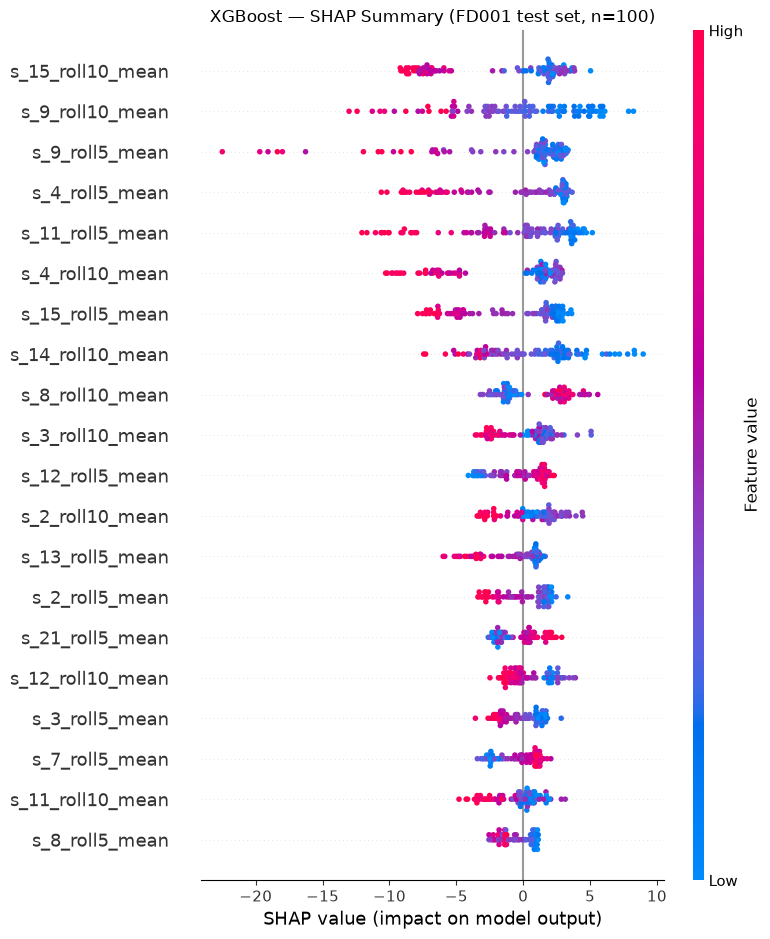

In [5]:
# Compute SHAP values for all test samples
xgb_shap_values = xgb_explainer._explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    xgb_shap_values,
    X_test,
    feature_names=xgb_features,
    plot_type="dot",
    show=False,
)
plt.title(f"XGBoost — SHAP Summary (FD001 test set, n={len(X_test)})")
plt.tight_layout()
plt.show()

### 3.2 Global Bar Plot — Mean |SHAP| per Feature

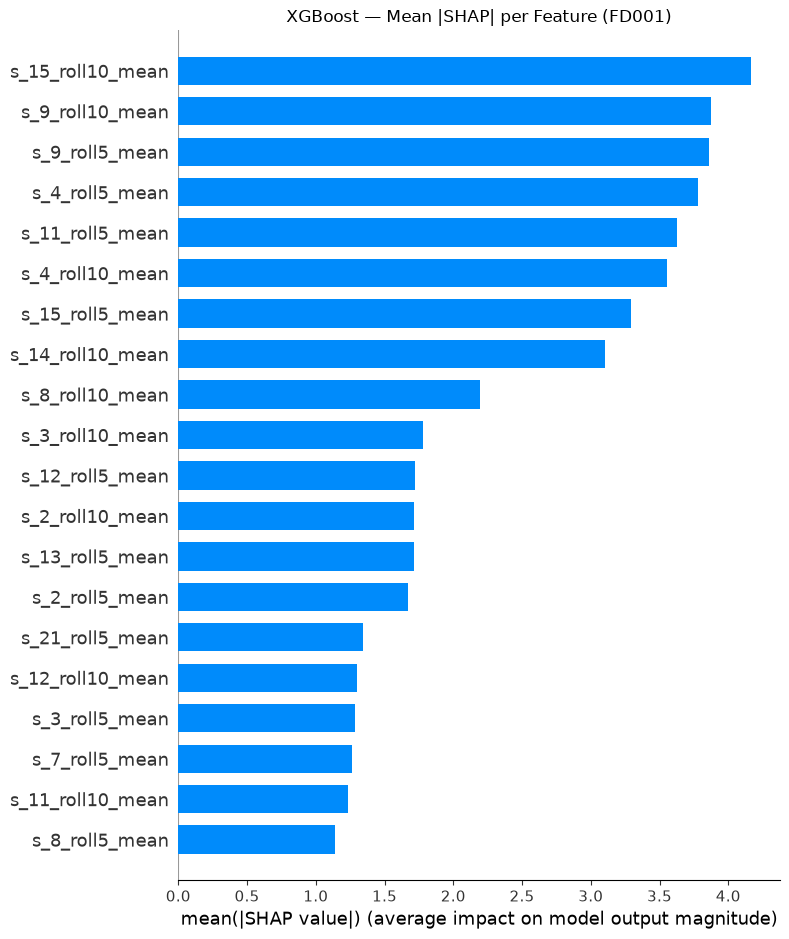

In [6]:
plt.figure(figsize=(8, 5))
shap.summary_plot(
    xgb_shap_values,
    X_test,
    feature_names=xgb_features,
    plot_type="bar",
    show=False,
)
plt.title("XGBoost — Mean |SHAP| per Feature (FD001)")
plt.tight_layout()
plt.show()

### 3.3 Per-Engine Explanation — Waterfall Plot

Pick the engine with the largest prediction error to see why the model struggled.

Worst-error sample: index=44, true_RUL=114.0, pred_RUL=54.7, error=59.3


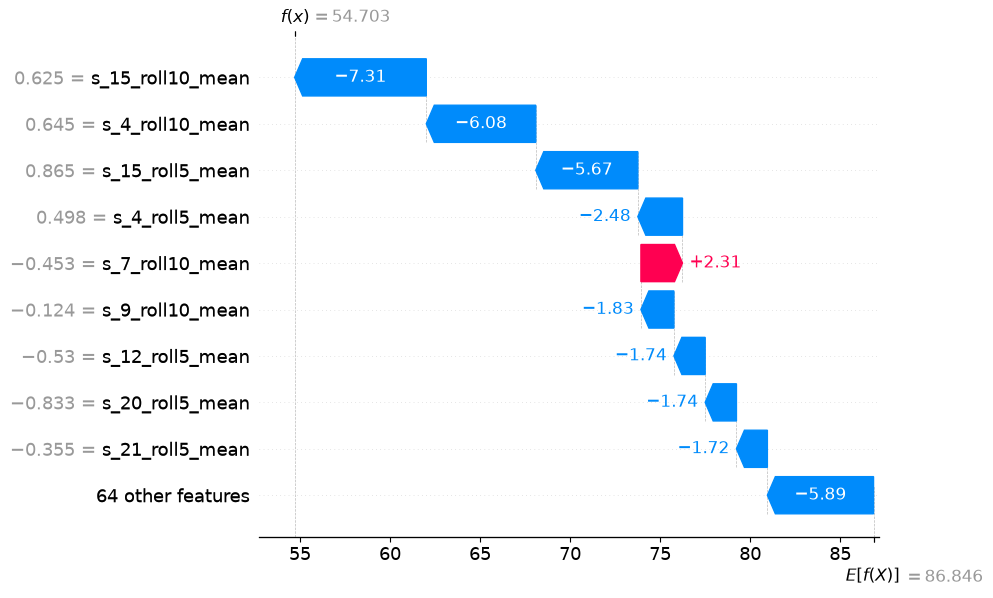

In [7]:
preds_xgb = xgb_model.predict(X_test)
errors = np.abs(preds_xgb - y_test.to_numpy())
worst_idx = int(np.argmax(errors))

print(
    f"Worst-error sample: index={worst_idx}, "
    f"true_RUL={y_test.iloc[worst_idx]:.1f}, "
    f"pred_RUL={preds_xgb[worst_idx]:.1f}, "
    f"error={errors[worst_idx]:.1f}"
)

explanation_obj = xgb_explainer._explainer(X_test)
shap.plots.waterfall(explanation_obj[worst_idx], show=True)

### 3.4 Structured `ExplanationResult` for One Test Sample

In [8]:
sample_result = xgb_explainer.explain_tabular(
    X_test.iloc[[worst_idx]],
    prediction=float(preds_xgb[worst_idx]),
)

print("ExplanationResult — top-5 features:")
top5 = dict(list(sample_result.feature_importances.items())[:5])
for feat, imp in top5.items():
    print(f"  {feat:35s}: {imp:.4f}")

print("\nJSON preview (explanation_metadata):")
print(json.dumps(sample_result.explanation_metadata, indent=2))

ExplanationResult — top-5 features:
  s_15_roll10_mean                   : 7.3096
  s_4_roll10_mean                    : 6.0797
  s_15_roll5_mean                    : 5.6656
  s_4_roll5_mean                     : 2.4805
  s_7_roll10_mean                    : 2.3085

JSON preview (explanation_metadata):
{
  "explainer_type": "TreeExplainer",
  "background_n": 0,
  "shap_values_1d": [
    -0.5252410173416138,
    0.0227618720382452,
    0.0,
    -0.1064135804772377,
    -0.17094755172729492,
    -0.10692296177148819,
    0.6128339767456055,
    -0.6962557435035706,
    0.14182434976100922,
    0.048616938292980194,
    -0.89865642786026,
    -0.4465612471103668,
    0.2611601650714874,
    -0.44287148118019104,
    -0.10646223276853561,
    -0.35491958260536194,
    0.11295348405838013,
    0.4052961468696594,
    -1.4372302293777466,
    -2.4804584980010986,
    -0.0807541087269783,
    -0.656425416469574,
    1.3813928365707397,
    0.41236189007759094,
    -1.7364509105682373,
    -0.

## 4. GRU — GradientExplainer

`shap.GradientExplainer` backpropagates SHAP values through the PyTorch
computation graph.  It is the recommended method for sequence models because it
is faster than `KernelExplainer` and more broadly compatible than `DeepExplainer`
when Transformer layers are involved.

We use 100 random training windows as the background reference.

In [9]:
GRU_AVAILABLE = False
GRU_SKIP_REASON = ""
try:
    gru_model, gru_features, gru_checkpoint = load_sequence_model_from_registry(
        model_name="gru_rul", dataset=DATASET, device_name="cpu"
    )
except FileNotFoundError as exc:
    GRU_SKIP_REASON = str(exc)
    print(f"Skipping GRU sections: {GRU_SKIP_REASON}")
else:
    rng = np.random.default_rng(42)
    bg_indices = rng.choice(len(train_windows), size=min(100, len(train_windows)), replace=False)
    background_windows = train_windows[bg_indices]  # (100, T, F)
    gru_explainer = SHAPExplainer.for_lstm_gru(
        gru_model, background_windows, gru_features,
        dataset=DATASET, model_name="gru_rul", device_name="cpu"
    )
    GRU_AVAILABLE = True
    print(f"GRU loaded — input_size={gru_checkpoint['input_size']}, "
          f"window_size={gru_checkpoint['config']['window_size']}")

GRU loaded — input_size=73, window_size=30


### 4.1 Per-Feature Importance — Averaged Over the Window

Select the final (most recent) test window for the engine with the highest
predicted degradation.

In [10]:
import torch

if not GRU_AVAILABLE:
    print(f"GRU explanation skipped: {GRU_SKIP_REASON}")
else:
    # Pick the last available window for a high-risk engine
    sample_window = test_windows[-1]  # (T, F)
    sample_batch = sample_window[np.newaxis]
    sample_tensor = torch.as_tensor(sample_batch, dtype=torch.float32)
    with torch.no_grad():
        gru_prediction = float(gru_model(sample_tensor).cpu().reshape(-1)[0])
    # Pass the prediction explicitly for compatibility with SHAP >= 0.52,
    # whose GradientExplainer no longer exposes a public `.model` attribute.
    result_gru = gru_explainer.explain_sequence(sample_batch, prediction=gru_prediction)
    print(f"Predicted RUL: {result_gru.rul_prediction:.1f} cycles")
    print("\nTop-5 features by mean |SHAP| over the window:")
    for feat, imp in list(result_gru.feature_importances.items())[:5]:
        print(f"  {feat:35s}: {imp:.6f}")

Predicted RUL: 19.2 cycles

Top-5 features by mean |SHAP| over the window:
  s_14_roll10_mean                   : 0.397811
  s_14_roll5_mean                    : 0.291226
  s_14_roll10_std                    : 0.251256
  s_9_roll5_mean                     : 0.226003
  s_9                                : 0.225297


### 4.2 SHAP Heatmap — Attribution Over Time

Each cell `[t, f]` shows how strongly feature *f* at timestep *t* pushed the
RUL prediction up (positive = more life remaining) or down (negative = closer
to failure).

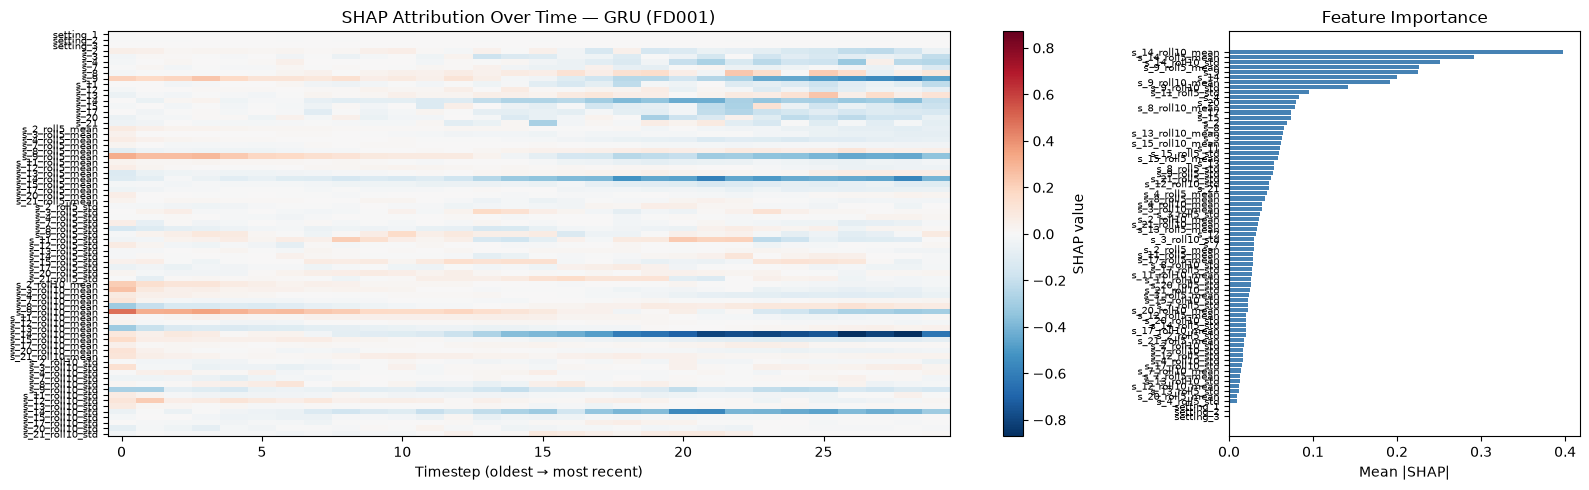

In [11]:
if not GRU_AVAILABLE:
    print(f"GRU heatmap skipped: {GRU_SKIP_REASON}")
else:
    sv_2d = np.array(result_gru.shap_values_full)  # (T, F)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [3, 1]})

# -- Heatmap
    im = axes[0].imshow(
        sv_2d.T, aspect="auto",
        cmap="RdBu_r", vmin=-np.abs(sv_2d).max(), vmax=np.abs(sv_2d).max()
    )
    axes[0].set_yticks(range(len(gru_features)))
    axes[0].set_yticklabels(gru_features, fontsize=7)
    axes[0].set_xlabel("Timestep (oldest → most recent)")
    axes[0].set_title("SHAP Attribution Over Time — GRU (FD001)")
    plt.colorbar(im, ax=axes[0], label="SHAP value")

# -- Bar: mean |SHAP| per feature
    mean_abs = np.abs(sv_2d).mean(axis=0)   # (F,)
    order = np.argsort(mean_abs)             # ascending for horizontal bar
    axes[1].barh(range(len(gru_features)), mean_abs[order], color="steelblue")
    axes[1].set_yticks(range(len(gru_features)))
    axes[1].set_yticklabels([gru_features[i] for i in order], fontsize=7)
    axes[1].set_xlabel("Mean |SHAP|")
    axes[1].set_title("Feature Importance")

    plt.tight_layout()
    plt.show()

### 4.3 Global Feature Importance — All Test Windows

Compute gradient SHAP for a subset of test windows and average to get a global
picture of which features the GRU relies on.

Global feature importance (GRU, FD001):
   1. s_11                               : 0.274179
   2. s_8                                : 0.257126
   3. s_4                                : 0.244298
   4. s_12_roll10_mean                   : 0.238039
   5. s_13                               : 0.237354
   6. s_11_roll10_mean                   : 0.231831
   7. s_20                               : 0.229801
   8. s_8_roll10_mean                    : 0.228080
   9. s_15                               : 0.228027
  10. s_13_roll10_mean                   : 0.228013


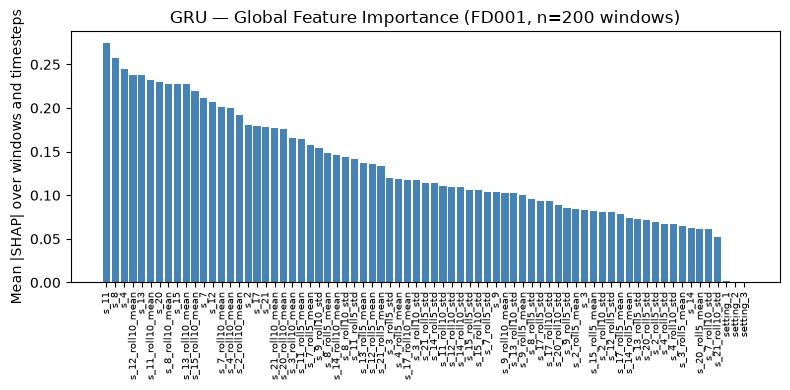

In [12]:
import torch

if not GRU_AVAILABLE:
    print(f"GRU global importance skipped: {GRU_SKIP_REASON}")
else:
    # Limit to 200 windows for speed (increase if memory allows)
    n_explain = min(200, len(test_windows))
    sample_indices = rng.choice(len(test_windows), size=n_explain, replace=False)
    explain_tensor = torch.as_tensor(
        test_windows[sample_indices], dtype=torch.float32
    )
    all_shap = gru_explainer._explainer.shap_values(explain_tensor)
    all_shap_arr = np.asarray(all_shap)
    # SHAP 0.52 adds a final output axis for single-output PyTorch models.
    if all_shap_arr.ndim == 4 and all_shap_arr.shape[-1] == 1:
        all_shap_arr = all_shap_arr[..., 0]
    if all_shap_arr.shape != tuple(explain_tensor.shape):
        raise ValueError(f"Unexpected GRU SHAP shape: {all_shap_arr.shape}")
    global_importance = np.abs(all_shap_arr).mean(axis=(0, 1))  # (F,)
    order = np.argsort(global_importance)[::-1]
    print("Global feature importance (GRU, FD001):")
    for rank, idx in enumerate(order[:10], 1):
        print(f"  {rank:2d}. {gru_features[idx]:35s}: {global_importance[idx]:.6f}")
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(gru_features)), global_importance[order], color="steelblue")
    plt.xticks(range(len(gru_features)), [gru_features[i] for i in order], rotation=90, fontsize=7)
    plt.ylabel("Mean |SHAP| over windows and timesteps")
    plt.title(f"GRU — Global Feature Importance (FD001, n={n_explain} windows)")
    plt.tight_layout()
    plt.show()

## 5. ExplanationResult JSON Preview

This is the exact JSON the Milestone 2.x `/predict/rul/explain` endpoint will
return.  Schema is documented in `docs/SCHEMAS.md`.

In [13]:
if not GRU_AVAILABLE:
    print(f"GRU JSON preview skipped: {GRU_SKIP_REASON}")
else:
    # Truncate shap_values_full in the printout so it fits on screen
    preview = result_gru.to_dict()
    if preview["shap_values_full"] is not None:
        T, F = len(preview["shap_values_full"]), len(preview["shap_values_full"][0])
        preview["shap_values_full"] = f"<array shape ({T}, {F}) — omitted for brevity>"
    print(json.dumps(preview, indent=2))

{
  "model_name": "gru_rul",
  "dataset": "FD001",
  "rul_prediction": 19.202592849731445,
  "feature_importances": {
    "s_14_roll10_mean": 0.3978105424269314,
    "s_14_roll5_mean": 0.29122584161030063,
    "s_14_roll10_std": 0.251256124553719,
    "s_9_roll5_mean": 0.22600276675212144,
    "s_9": 0.22529728873902763,
    "s_14": 0.19978397686064506,
    "s_9_roll10_mean": 0.19104821046893758,
    "s_9_roll10_std": 0.1415207689439467,
    "s_11_roll5_std": 0.09473098150624408,
    "s_4": 0.08385747817231079,
    "s_20": 0.0798413962434449,
    "s_8_roll10_mean": 0.0791006385694821,
    "s_17": 0.0739236837596371,
    "s_15": 0.07351178733067702,
    "s_2": 0.06955136294897098,
    "s_8": 0.06600588881792205,
    "s_13_roll10_mean": 0.06442124836468703,
    "s_3": 0.06247845130769539,
    "s_15_roll10_mean": 0.06140683673227155,
    "s_11": 0.06069344696699123,
    "s_15_roll5_std": 0.059368956743585756,
    "s_15_roll5_mean": 0.05870994755290782,
    "s_13": 0.05396946900940507,
   

## 6. Save Explanations to Disk

Persist the per-sample explanation JSON alongside the model registry artifacts
so Milestone 2.x can serve them without recomputing.

In [14]:
from pathlib import Path

explain_dir = Path(ML_ROOT) / "models" / "explanations" / DATASET
explain_dir.mkdir(parents=True, exist_ok=True)

xgb_path = explain_dir / f"xgboost_sample_{worst_idx}.json"
xgb_path.write_text(sample_result.to_json(), encoding="utf-8")
print(f"Saved XGBoost explanation: {xgb_path}")

if GRU_AVAILABLE:
    gru_path = explain_dir / "gru_last_window.json"
    gru_path.write_text(result_gru.to_json(), encoding="utf-8")
    print(f"Saved GRU explanation:     {gru_path}")
else:
    print(f"GRU explanation not saved: {GRU_SKIP_REASON}")

Saved XGBoost explanation: /home/silvanus/CODES/ipmp-platform/ml/models/explanations/FD001/xgboost_sample_44.json
Saved GRU explanation:     /home/silvanus/CODES/ipmp-platform/ml/models/explanations/FD001/gru_last_window.json


## 7. Next Steps

- **Milestone 2.1** — `serving/app/schemas.py` implements `ExplanationResponse` matching `docs/SCHEMAS.md`.
- **Milestone 2.2** — `POST /predict/rul/explain` calls `SHAPExplainer` cached in app state and returns `ExplanationResult.to_dict()`.
- **PatchTST explanations** — use `SHAPExplainer.for_patchtst()` once GPU-trained weights are committed to the registry.  The notebook workflow is identical to sections 4–5 above.